In [1]:
# Como funciona la WassDist?
# Estoy obteniendo flat losses en t ~ T. 
# No es normal, en teoria el modelo deberia poder mapear algo random a algo random. Al final la distribución de los outputs vagamente cambia.

from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import QDDPM, WassDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers  = 1000, 64, 40, 4, 9
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'


Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


Comparación WassDist entre los states en t=0 y el output de los scrambling circuits en cada t.

Text(0.5, 1.0, 'Evolution of the quantum state distribution through the scrambling circuits.\n Noise schedule: linear1')

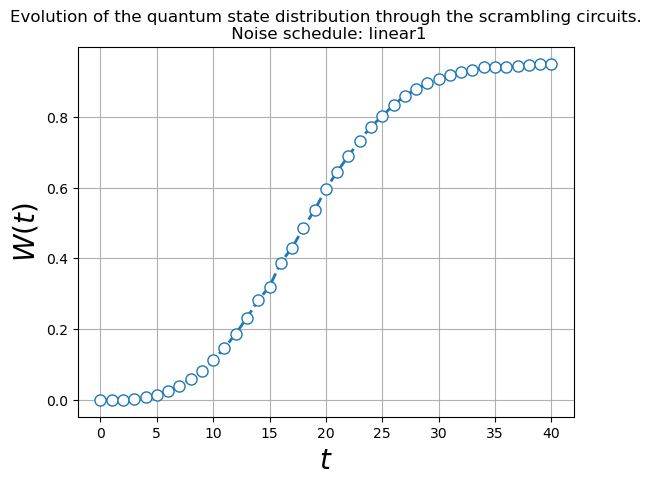

In [2]:
diffusion_schedule = 'linear1'
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass = np.load(dir / filename)

plt.plot(wass, 'o--', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$W(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
plt.grid(True)
plt.title(f'Evolution of the quantum state distribution through the scrambling circuits.\n Noise schedule: {diffusion_schedule}')

Ahora WassDist entre t=40 y t=39. Idealmente tendria que ser ~0.

In [3]:
# Wasserstein distance
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
diffused_states = torch.from_numpy(np.load(dir / filename))

T=n_timesteps
wass = WassDistance(diffused_states[T], diffused_states[T-1])
print(wass)

tensor(0.8750)


Why??????? Si son dos distribuciones prácticamente aleatorias...

Quizás el problema es que hay pocos samples. N=1000 quizás sea demasiado poco como para representar significativamente una distribución aleatoria en un espacio de Hilbert de 2^6 estados. (No tiene sentido porque eso son 64 estados, y con 1000 samples yo creo que llenamos bien la hiper esfera de Bloch, pero bueno).

  0%|          | 0/41 [00:00<?, ?it/s]

 27%|██▋       | 11/41 [00:25<01:46,  3.54s/it]/home/angel/miniconda3/envs/ogQDDPMcuda/lib/python3.11/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)
100%|██████████| 41/41 [01:48<00:00,  2.64s/it]


Text(0.5, 1.0, 'Evolution of the quantum state distribution through the scrambling circuits.\n Noise schedule: linear1')

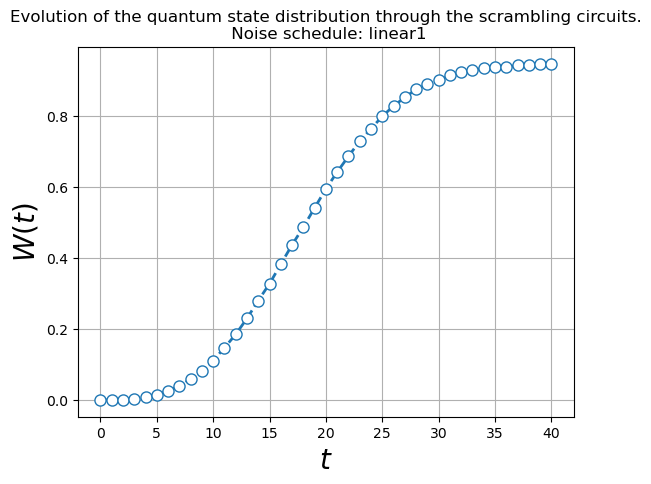

In [5]:
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps  = 5923, 64, 40
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'

# Wasserstein distance
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
diffused_states = torch.from_numpy(np.load(dir / filename))

wass = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps+1)):
    np.random.seed()
    wass[t] = WassDistance(diffused_states[0], diffused_states[t]).detach().numpy()

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
np.save(dir / filename, wass)

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass = np.load(dir / filename)

plt.plot(wass, 'o--', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$W(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
plt.grid(True)
plt.title(f'Evolution of the quantum state distribution through the scrambling circuits.\n Noise schedule: {diffusion_schedule}')

In [9]:
# Wasserstein distance
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
diffused_states = torch.from_numpy(np.load(dir / filename))

import ot
def WassDistance_edit(Set1, Set2):
    '''
        calculate the Wasserstein distance between two sets of quantum states
        the cost matrix is the inter trace distance between sets S1, S2
    '''
    D = 1. - torch.abs(Set1.conj() @ Set2.T)**2.
    emt = torch.empty(0)
    Wass_dis = ot.emd2(emt, emt, M=D, numItermax=1000000)
    return Wass_dis

T=n_timesteps
wass = WassDistance_edit(diffused_states[T], diffused_states[T-1])
print(wass)

tensor(0.8423)


Ok, ha disminuido pero no significativamente...